# 17 &middot; Skinning Eigenmodes: a Subspace that Can Rotate

A high-resolution beam is *accurate* but *slow* (tutorial&nbsp;10): every Backward-
Euler step solves a sparse system as big as the mesh. **Reduced-order modeling**
escapes this by restricting the motion to a small **subspace**

$$ x \;=\; B\,z + q , \qquad z\in\mathbb{R}^r,\quad r \ll n\,\text{dim}, $$

and solving for the $r$ subspace coordinates $z$ instead of all $n\,\text{dim}$
vertex DOFs. The basis $B$ is built **once**, offline. The question is *which*
basis &mdash; and the answer hinges on one thing: **can the subspace rotate?**

* **Linear Modal Analysis (LMA)** uses the lowest vibration modes as *displacement*
  columns: $x = X + B_{\text{lma}}z$. Fast, but a sum of fixed displacement fields
  is **linear** in $z$ &mdash; and rotation is *not* a linear function of position.
  LMA literally cannot turn the rest shape.
* **Skinning eigenmodes** use the same Laplacian eigenvectors as **skinning
  weights** and attach a small *affine transform* to each: $x = B_{\text{skin}}z$,
  where $z$ stacks per-bone $2\times3$ transforms. Affine transforms **contain
  rotation**, so this subspace turns the shape exactly &mdash; for the same solve
  cost.

We will (1) feel the cost of the full solve, (2) show the subspace shrinks the
**solve** (not the integration), (3) watch a cantilever sag and see LMA fail to
rotate while skinning tracks the full reference, and (4) rotate the rest shape a
full turn and measure each subspace's reconstruction error.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import time
import numpy as np
import scipy as sp
import scipy.sparse as sps
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import simkit
import simkit.energies as energies
from simkit.solvers.NewtonSolver import NewtonSolver, NewtonSolverParams
import utils

import warnings
from scipy.linalg import LinAlgWarning
warnings.filterwarnings("ignore", category=LinAlgWarning)   # stiff pin -> benign ill-conditioning

os.makedirs("media", exist_ok=True)

FULL_C = "#d62728"   # full-space (reference / "slow")
LMA_C  = "#1f77b4"   # linear modal analysis
SKIN_C = "#2ca02c"   # skinning eigenmodes
WALL_FACE = "#cfe8df"
WALL_EDGE = "#2a7f62"
PIN_C  = "#3182bd"

## A neo-Hookean beam, sagging under gravity, with inertia

We reuse the cantilever of tutorial&nbsp;10 but now make it **dynamic**: each step
is one **Backward-Euler** solve of the incremental potential

$$
x_{n+1} \;=\; \arg\min_x \;\; \tfrac{1}{2h^2}\,\lVert x-\tilde x\rVert^2_M
\;+\; \Psi_{\text{neo}}(x) \;-\; f_g^{\top}x \;+\; \tfrac12\lVert x_{\text{pin}}-X_{\text{pin}}\rVert^2_K ,
$$

with momentum target $\tilde x = 2x_n - x_{n-1}$ (i.e. $x_n + h v_n$), full-order
**neo-Hookean** elasticity, gravity, and a stiff penalty clamping the left wall.
`BeamSim` wraps the mesh, the precomputed operators, and a single Newton step
&mdash; and takes an optional subspace `(B, q)`. With `B = I` it solves the full
per-vertex system; with a reduced `B` it solves for `z` via the **Galerkin
projection** $B^{\top} g$, $B^{\top} H B$ (full integration &mdash; we evaluate the
real energy and project, no cubature).

In [2]:
class BeamSim:
    '''Backward-Euler neo-Hookean cantilever. Optional subspace x = B z + q.'''

    def __init__(self, nx, ny, ym=3000.0, pr=0.4, rho=1.0, h=2e-2,
                 B=None, q=None, K_pin=1e7, width=4.0, height=0.5):
        self.X, self.T = utils.triangulated_grid(nx, ny, width=width, height=height)
        self.n, self.dim = self.X.shape
        self.h = h
        self.J   = simkit.deformation_jacobian(self.X, self.T)
        self.vol = simkit.volume(self.X, self.T)
        mu, lam  = simkit.ympr_to_lame(ym, pr)
        self.mu  = np.full((len(self.T), 1), mu)
        self.lam = np.full((len(self.T), 1), lam)
        self.Mk  = sps.kron(simkit.massmatrix(self.X, self.T, rho=rho),
                            sps.identity(self.dim)).tocsc()
        self.fg  = simkit.gravity_force(self.X, self.T, a=-9.8, rho=rho).reshape(-1, 1)
        pin = np.where(self.X[:, 0] <= self.X[:, 0].min() + 1e-6)[0]
        self.pin_idx = pin
        self.Qp, self.bp = simkit.dirichlet_penalty(pin, self.X[pin], self.n, K_pin)

        # subspace: x = B z + q   (B = identity => full space)
        self.B = sps.identity(self.n * self.dim).tocsc() if B is None else B
        self.q = np.zeros((self.B.shape[0], 1)) if q is None else q.reshape(-1, 1)
        self.tip = int(np.argmax(self.X[:, 0]))
        self.xtilde = None

    # --- full-space incremental potential at positions x (flattened col) ---
    def _x(self, z):  return self.B @ z + self.q

    def energy(self, z):
        x = self._x(z); xn = x.reshape(-1, self.dim)
        dxt = x - self.xtilde
        E_kin = 0.5 / self.h**2 * (dxt.T @ (self.Mk @ dxt))[0, 0]
        E_el  = energies.macklin_mueller_neo_hookean_energy_x(xn, self.J, self.mu, self.lam, self.vol)
        E_g   = -(self.fg.T @ x)[0, 0]
        E_pin = 0.5 * (x.T @ (self.Qp @ x))[0, 0] + (self.bp.T @ x)[0, 0]
        return E_kin + E_el + E_g + E_pin

    def gradient(self, z):
        x = self._x(z); xn = x.reshape(-1, self.dim)
        g = (self.Mk / self.h**2) @ (x - self.xtilde)
        g += energies.macklin_mueller_neo_hookean_gradient_x(xn, self.J, self.mu, self.lam, self.vol)
        g += -self.fg + self.Qp @ x + self.bp
        return self.B.T @ g

    def hessian(self, z):
        x = self._x(z); xn = x.reshape(-1, self.dim)
        H = self.Mk / self.h**2 + self.Qp
        H = H + energies.macklin_mueller_neo_hookean_hessian_x(xn, self.J, self.mu, self.lam, self.vol, psd=True)
        return self.B.T @ (H @ self.B)

    def rest_z(self):
        '''Subspace coordinates of the rest shape (mass-weighted projection).'''
        return simkit.project_into_subspace(self.X.reshape(-1, 1) - self.q, self.B, M=self.Mk)

    def step(self, z, z_prev, iters=30):
        '''One Backward-Euler step; Newton with line search (required for stability).'''
        self.xtilde = self.B @ (2 * z - z_prev) + self.q          # x_n + h v_n
        solver = NewtonSolver(self.energy, self.gradient, self.hessian,
                              NewtonSolverParams(max_iter=iters, do_line_search=True))
        return solver.solve(z.copy())

    def simulate(self, n_steps=80):
        '''Drop from rest under gravity; return per-step poses and tip height.'''
        z = self.rest_z(); z_prev = z.copy()
        states, tip_y = [self._x(z).reshape(self.n, self.dim)], [self.X[self.tip, 1]]
        for _ in range(n_steps):
            z, z_prev = self.step(z, z_prev), z
            U = self._x(z).reshape(self.n, self.dim)
            states.append(U); tip_y.append(U[self.tip, 1])
        return np.array(states), np.array(tip_y)

## The full solve is slow

A genuinely high-resolution beam (here ~3600 vertices, ~7200 DOFs). We assemble
one Backward-Euler system at a deformed state and time the **linear solve** alone
and the **gradient + Hessian evaluation** alone &mdash; the two halves of every
Newton iteration. The solve is the part that grows with mesh size.

In [3]:
hi = BeamSim(120, 30)                       # high-res "slow" beam
print(f"high-res mesh: {hi.n} vertices, {hi.T.shape[0]} triangles, {hi.n*hi.dim} DOFs")

# a representative deformed state + a momentum target, so the system is realistic
rng = np.random.RandomState(0)
x_def = (hi.X + 0.05 * rng.randn(hi.n, hi.dim)).reshape(-1, 1)
hi.xtilde = hi.X.reshape(-1, 1)
z_def = x_def                                # full space: z == x

def time_call(fn, inner=1, rep=7):
    '''Min over `rep` batches of `inner` calls each -> robust for sub-ms timings.'''
    best = float("inf")
    for _ in range(rep):
        t0 = time.perf_counter()
        for _ in range(inner):
            fn()
        best = min(best, (time.perf_counter() - t0) / inner)
    return best

# eval = assemble gradient + Hessian; solve = the linear system, timed in isolation
def assemble_full():
    return hi.hessian(z_def).tocsc(), hi.gradient(z_def)
H_full, g_full = assemble_full()
t_eval_full  = time_call(assemble_full, inner=1, rep=5)
t_solve_full = time_call(lambda: sps.linalg.spsolve(H_full, -g_full), inner=3, rep=7)
print(f"full-space eval (grad+Hess): {t_eval_full*1e3:7.1f} ms")
print(f"full-space linear solve    : {t_solve_full*1e3:7.1f} ms")

high-res mesh: 3600 vertices, 6902 triangles, 7200 DOFs


full-space eval (grad+Hess):    24.9 ms
full-space linear solve    :    13.1 ms


## Two subspaces, built once

`simkit.linear_modal_analysis` returns the lowest $k$ vibration modes as a
displacement basis $B_{\text{lma}}\in\mathbb{R}^{n\,\text{dim}\times k}$.
`simkit.skinning_eigenmodes` returns the Laplacian eigenvector **weights** $W$ and
the corresponding **LBS Jacobian** $B_{\text{skin}}\in\mathbb{R}^{n\,\text{dim}
\times 6k}$ (each of the $k$ modes carries a $2\times3$ affine transform = 6 DOFs
in 2D). Same $k$, but skinning spends its extra columns buying *rotation*.

k = 12 modes
  LMA  basis:  72 columns  (k displacement modes)
  SKIN basis:  72 columns  (k modes x 6 affine DOFs)


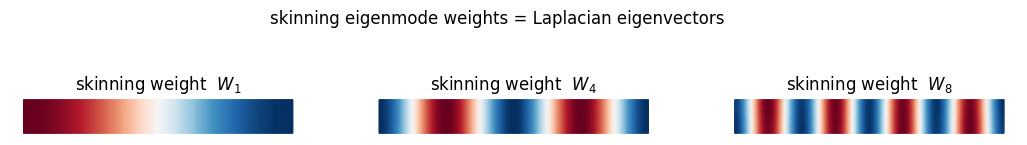

In [12]:
k = 12
E_lma,  B_lma  = simkit.linear_modal_analysis(hi.X, hi.T, k*6)
W, E_s, B_skin = simkit.skinning_eigenmodes(hi.X, hi.T, k)
B_lma  = np.asarray(B_lma)
B_skin = np.asarray(B_skin)
print(f"k = {k} modes")
print(f"  LMA  basis: {B_lma.shape[1]:3d} columns  (k displacement modes)")
print(f"  SKIN basis: {B_skin.shape[1]:3d} columns  (k modes x 6 affine DOFs)")

# show three skinning weight fields W (the partition the affine bones blend over)
fig, axes = plt.subplots(1, 3, figsize=(13, 2.2))
for ax, j in zip(axes, [1, 4, 8]):
    tc = ax.tripcolor(hi.X[:, 0], hi.X[:, 1], hi.T, W[:, j], shading="gouraud", cmap="RdBu")
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(f"skinning weight  $W_{{{j}}}$")
fig.suptitle("skinning eigenmode weights = Laplacian eigenvectors")
plt.show()

## The subspace shrinks the *solve*, not the *integration*

Every Newton iteration is **evaluate** (assemble gradient + Hessian) then
**solve** (one linear system). With full integration the reduced model still
evaluates the *real* neo-Hookean energy on every element and projects it
($B^{\top}g$, $B^{\top}HB$), so its **eval cost is unchanged**. What collapses is
the **solve**: from an $n\,\text{dim}\times n\,\text{dim}$ sparse system to a tiny
dense $r\times r$ one.

**Plot 1** &mdash; linear-solve time vs. number of skinning eigenmodes, with the
full-space solve drawn as a red line towering above. **Plot 2** &mdash; the eval
(grad+Hess+projection) time, full vs. subspace: essentially equal, because the
integration is *not* reduced.

  skinning k= 2 (r= 12): solve  0.00269 ms   eval   24.1 ms
  skinning k= 5 (r= 30): solve  0.00659 ms   eval   24.1 ms


  skinning k=10 (r= 60): solve  0.01590 ms   eval   25.0 ms


  skinning k=20 (r=120): solve  0.04868 ms   eval   27.2 ms


  skinning k=40 (r=240): solve  0.17987 ms   eval   29.5 ms


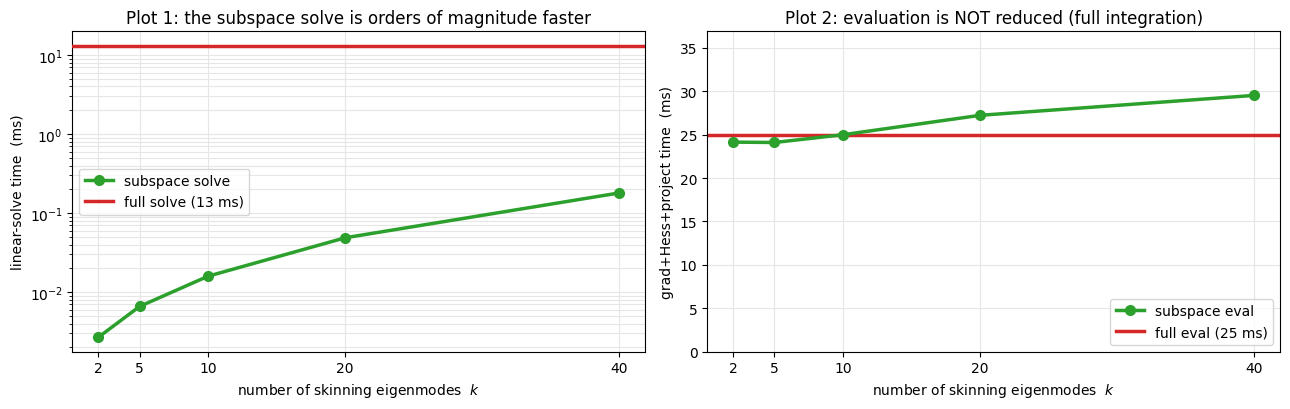

In [5]:
mode_counts = [2, 5, 10, 20, 40]
solve_red, eval_red = [], []
for kk in mode_counts:
    _, _, Bk = simkit.skinning_eigenmodes(hi.X, hi.T, kk)
    Bk = np.asarray(Bk)
    def assemble_red(Bk=Bk):
        x = x_def; xn = x.reshape(-1, hi.dim)
        g = (hi.Mk / hi.h**2) @ (x - hi.xtilde)
        g += energies.macklin_mueller_neo_hookean_gradient_x(xn, hi.J, hi.mu, hi.lam, hi.vol)
        g += -hi.fg + hi.Qp @ x + hi.bp
        H = hi.Mk / hi.h**2 + hi.Qp
        H = H + energies.macklin_mueller_neo_hookean_hessian_x(xn, hi.J, hi.mu, hi.lam, hi.vol, psd=True)
        return Bk.T @ (H @ Bk), Bk.T @ g
    Hz, gz = assemble_red(Bk)                                  # assemble once
    te = time_call(assemble_red, inner=1, rep=5)               # eval (full integration + projection)
    ts = time_call(lambda Hz=Hz, gz=gz: np.linalg.solve(Hz, -gz), inner=200, rep=7)  # solve, isolated
    eval_red.append(te * 1e3); solve_red.append(ts * 1e3)
    print(f"  skinning k={kk:2d} (r={Bk.shape[1]:3d}): solve {solve_red[-1]:8.5f} ms   eval {eval_red[-1]:6.1f} ms")

mc = np.array(mode_counts)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))

axL.plot(mc, solve_red, "-o", color=SKIN_C, lw=2.5, ms=7, label="subspace solve", zorder=3)
axL.axhline(t_solve_full * 1e3, color=FULL_C, lw=2.5, ls="-", zorder=4,
            label=f"full solve ({t_solve_full*1e3:.0f} ms)")
axL.set_yscale("log"); axL.set_xticks(mc)
axL.set_xlabel("number of skinning eigenmodes  $k$"); axL.set_ylabel("linear-solve time  (ms)")
axL.set_title("Plot 1: the subspace solve is orders of magnitude faster")
axL.legend(loc="center left"); axL.grid(True, which="both", color="0.9")

axR.plot(mc, eval_red, "-o", color=SKIN_C, lw=2.5, ms=7, label="subspace eval", zorder=3)
axR.axhline(t_eval_full * 1e3, color=FULL_C, lw=2.5, label=f"full eval ({t_eval_full*1e3:.0f} ms)")
axR.set_xticks(mc); axR.set_ylim(0, max(t_eval_full * 1e3, max(eval_red)) * 1.25)
axR.set_xlabel("number of skinning eigenmodes  $k$"); axR.set_ylabel("grad+Hess+project time  (ms)")
axR.set_title("Plot 2: evaluation is NOT reduced (full integration)")
axR.legend(loc="lower right"); axR.grid(True, color="0.9")
fig.tight_layout(); fig.savefig("media/17_timing.png", dpi=130, bbox_inches="tight"); plt.show()

## Fast solve &mdash; but does it look right?

Cost is only half the story. We now run the **same** dynamic sag in all three
spaces on a softer beam (so the free end swings through a large angle) and play
them side by side: the full-order reference, LMA, and skinning. Watch the tip.

final tip height:  full -3.48   LMA -0.56   skin -3.01
LMA  under-rotates: tip only reaches 16% of the full droop
area ratio [min,max]:  full (np.float64(0.81), np.float64(1.23))   LMA (np.float64(0.98), np.float64(1.02))   skin (np.float64(0.82), np.float64(1.17))


saved media/17_dynamics.mp4



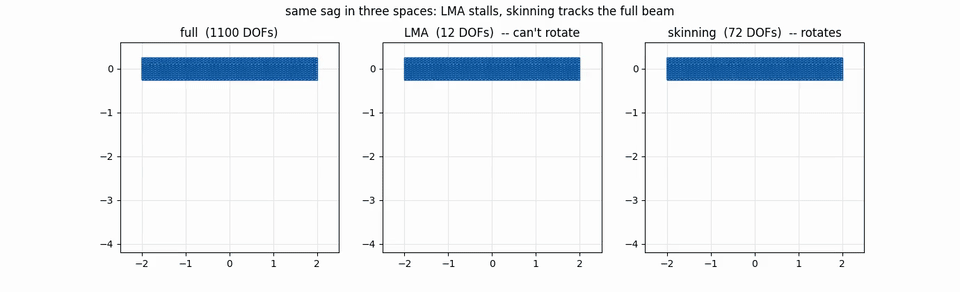

In [6]:
nx, ny = 50, 11
full = BeamSim(nx, ny)
Xs, Ts = full.X, full.T
El, Bl = simkit.linear_modal_analysis(Xs, Ts, k)
Ws, Es2, Bs = simkit.skinning_eigenmodes(Xs, Ts, k)
lma  = BeamSim(nx, ny, B=np.asarray(Bl), q=Xs.reshape(-1, 1))     # x = X + B z
skin = BeamSim(nx, ny, B=np.asarray(Bs))                          # x = B z

st_full, ty_full = full.simulate(80)
st_lma,  ty_lma  = lma.simulate(80)
st_skin, ty_skin = skin.simulate(80)

def area_ratio(U):
    a = lambda V: 0.5 * ((V[Ts[:,1],0]-V[Ts[:,0],0])*(V[Ts[:,2],1]-V[Ts[:,0],1])
                       -  (V[Ts[:,1],1]-V[Ts[:,0],1])*(V[Ts[:,2],0]-V[Ts[:,0],0]))
    r = a(U) / a(Xs); return r.min(), r.max()
print(f"final tip height:  full {ty_full[-1]:+.2f}   LMA {ty_lma[-1]:+.2f}   skin {ty_skin[-1]:+.2f}")
print(f"LMA  under-rotates: tip only reaches {abs(ty_lma[-1]/ty_full[-1])*100:.0f}% of the full droop")
print(f"area ratio [min,max]:  full {tuple(round(v,2) for v in area_ratio(st_full[-1]))}"
      f"   LMA {tuple(round(v,2) for v in area_ratio(st_lma[-1]))}"
      f"   skin {tuple(round(v,2) for v in area_ratio(st_skin[-1]))}")

panels = [
    {"states": st_full, "T": Ts, "title": f"full  ({full.n*full.dim} DOFs)"},
    {"states": st_lma,  "T": Ts, "title": f"LMA  ({Bl.shape[1]} DOFs)  -- can't rotate"},
    {"states": st_skin, "T": Ts, "title": f"skinning  ({Bs.shape[1]} DOFs)  -- rotates"},
]
fig, anim = utils.animate_meshes_grid(panels, lims=((-2.5, 2.5), (-4.2, 0.6)), fps=20,
                                      suptitle="same sag in three spaces: LMA stalls, skinning tracks the full beam")
out = utils.save_anim(anim, "media/17_dynamics.mp4", fps=20)
print("saved", out)
html = utils.show_anim(anim, fps=16, width=960)
plt.close(fig)
html

## The decisive test: rotate the rest shape a full turn

The dynamics hinted at it; this proves it. Take the **rest** beam, rotate it by
$\theta$ through a full $360^\circ$, and ask each subspace to **reproduce** that
rigid rotation: project the rotated mesh into the subspace in the **mass norm**
(`project_into_subspace` with $M$), reconstruct $x = Bz+q$, and measure the
relative error $\lVert Bz+q - x_\theta\rVert_M / \lVert x_\theta\rVert_M$.

A pure rotation is a *rigid* motion &mdash; no strain, the lowest-energy thing a
body can do &mdash; yet **LMA cannot represent it**: its columns are fixed
displacement fields, and the error grows with the angle, peaking when the shape is
upside-down. **Skinning** carries a rotation in every bone's affine block, so it
reproduces the turn to machine precision at *every* angle.

In [7]:
Mk = sps.kron(simkit.massmatrix(Xs, Ts), sps.identity(2)).tocsc()
q_lma  = Xs.reshape(-1, 1)
q_skin = np.zeros((Xs.size, 1))
xr = Xs.reshape(-1, 1)

def reconstruct(y, B, q):
    z = simkit.project_into_subspace(y - q, B, M=Mk)
    return B @ z + q

def rel_err(rec, y):
    d = rec - y
    return float(np.sqrt((d.T @ Mk @ d)[0, 0]) / np.sqrt((y.T @ Mk @ y)[0, 0]))

angles = np.linspace(0, 360, 73)
targets, rec_lma, rec_skin, err_lma, err_skin = [], [], [], [], []
for deg in angles:
    th = np.deg2rad(deg)
    R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    y = (Xs @ R.T).reshape(-1, 1)
    rl = reconstruct(y, np.asarray(Bl), q_lma)
    rsk = reconstruct(y, np.asarray(Bs), q_skin)
    targets.append(y.reshape(-1, 2)); rec_lma.append(rl.reshape(-1, 2)); rec_skin.append(rsk.reshape(-1, 2))
    err_lma.append(rel_err(rl, y)); err_skin.append(rel_err(rsk, y))
err_lma, err_skin = np.array(err_lma), np.array(err_skin)
print(f"LMA  reconstruction error: 0 -> {err_lma.max():.3f} (peak at 180 deg) -> 0")
print(f"skin reconstruction error: max {err_skin.max():.1e}  (machine zero, all angles)")

LMA  reconstruction error: 0 -> 0.342 (peak at 180 deg) -> 0
skin reconstruction error: max 7.2e-10  (machine zero, all angles)


saved media/17_rotation_error.mp4



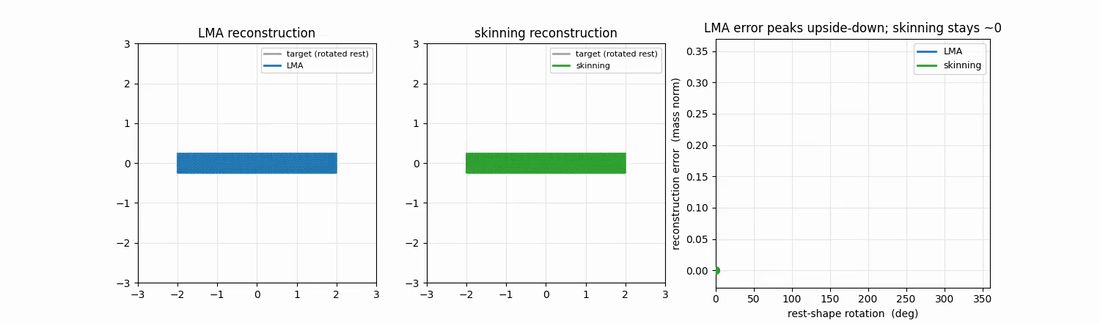

In [8]:
fig, (axA, axB, axR) = plt.subplots(1, 3, figsize=(15, 4.4),
                                    gridspec_kw={"width_ratios": [1, 1, 1.15]})

# --- panel A: LMA reconstruction (target ghosted underneath) ---
utils.setup_axes(axA, (-3.0, 3.0), (-3.0, 3.0), title="LMA reconstruction")
mtA = utils.PolyMeshArtist(axA, targets[0], Ts, facecolor="0.9", edgecolor="0.65", lw=0.4)
ml  = utils.PolyMeshArtist(axA, rec_lma[0], Ts, facecolor="none", edgecolor=LMA_C, lw=1.0)
axA.plot([], [], color="0.65", lw=2, label="target (rotated rest)")
axA.plot([], [], color=LMA_C, lw=2, label="LMA")
axA.legend(loc="upper right", fontsize=8)

# --- panel B: skinning reconstruction (target ghosted underneath) ---
utils.setup_axes(axB, (-3.0, 3.0), (-3.0, 3.0), title="skinning reconstruction")
mtB = utils.PolyMeshArtist(axB, targets[0], Ts, facecolor="0.9", edgecolor="0.65", lw=0.4)
msk = utils.PolyMeshArtist(axB, rec_skin[0], Ts, facecolor="none", edgecolor=SKIN_C, lw=1.0)
axB.plot([], [], color="0.65", lw=2, label="target (rotated rest)")
axB.plot([], [], color=SKIN_C, lw=2, label="skinning")
axB.legend(loc="upper right", fontsize=8)

# --- panel R: reconstruction error vs rotation angle ---
trace = utils.TracePlot(axR, angles, {"LMA": err_lma, "skinning": err_skin},
                        colors={"LMA": LMA_C, "skinning": SKIN_C},
                        xlabel="rest-shape rotation  (deg)", ylabel="reconstruction error  (mass norm)",
                        title="LMA error peaks upside-down; skinning stays ~0")

def update(i):
    mtA.update(targets[i]); ml.update(rec_lma[i])
    mtB.update(targets[i]); msk.update(rec_skin[i])
    trace.update(i)
    return ()

anim = FuncAnimation(fig, update, frames=len(angles), interval=1000/18, blit=False)
out = utils.save_anim(anim, "media/17_rotation_error.mp4", fps=18)
print("saved", out)
fig.savefig("media/17_rotation_error.png", dpi=130, bbox_inches="tight")
html = utils.show_anim(anim, fps=16, width=1100)
plt.close(fig)
html

## Does adding modes fix it? Integrate the error over a full turn

The curve above is for *one* fixed basis. The real question is how the error
behaves as we **grow the subspace**. For 20 different subspace sizes we integrate
the reconstruction error over the entire $360^\circ$ rotation &mdash; its average
over all angles &mdash; and plot it against the number of subspace DOFs.

Adding modes lets LMA chase the rotation a little better, so its turn-averaged
error decreases &mdash; but a *linear* basis can never **contain** a rotation, so
the error **plateaus far from zero** no matter how many modes we spend. Skinning
carries a rotation inside every bone's affine block, so it is exact at **every**
size &mdash; even a single bone (6 DOFs) reproduces the full turn to machine
precision.

LMA : up to 120 DOFs -> turn-averaged error plateaus at 0.024 (never rotates)
skin: up to 120 DOFs -> turn-averaged error max 5.4e-08 (exact at every size)


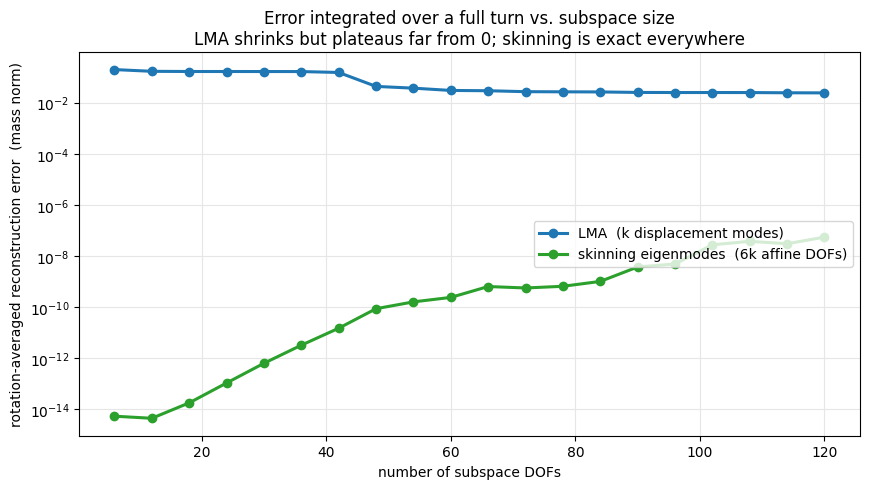

In [11]:
# integrate the reconstruction error over a full 360-degree turn, for 20 subspace sizes
mode_range = np.arange(1, 21)
ang_int = np.linspace(0, 360, 49)
Rg = [np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]]) for t in np.deg2rad(ang_int)]
Yg = [(Xs @ R.T).reshape(-1, 1) for R in Rg]
yn = np.array([float(np.sqrt((y.T @ Mk @ y)[0, 0])) for y in Yg])

def turn_avg_error(B, q):
    '''Reconstruction error averaged over the whole 360-degree rotation sweep.'''
    B = np.asarray(B); BMB = B.T @ (Mk @ B)
    errs = []
    for y, ym in zip(Yg, yn):
        z = np.linalg.solve(BMB, B.T @ (Mk @ (y - q)))
        d = B @ z + q - y
        errs.append(float(np.sqrt((d.T @ Mk @ d)[0, 0])) / ym)
    return float(np.mean(errs))

dof_lma, dof_skin, ei_lma, ei_skin = [], [], [], []
for kk in mode_range:
    _, Bl    = simkit.linear_modal_analysis(Xs, Ts, kk*6)
    _, _, Bs = simkit.skinning_eigenmodes(Xs, Ts, kk)
    dof_lma.append(Bl.shape[1]);  ei_lma.append(turn_avg_error(Bl, Xs.reshape(-1, 1)))
    dof_skin.append(Bs.shape[1]); ei_skin.append(turn_avg_error(Bs, np.zeros((Xs.size, 1))))
print(f"LMA : up to {dof_lma[-1]:3d} DOFs -> turn-averaged error plateaus at {min(ei_lma):.3f} (never rotates)")
print(f"skin: up to {dof_skin[-1]:3d} DOFs -> turn-averaged error max {max(ei_skin):.1e} (exact at every size)")

fig, ax = plt.subplots(figsize=(8.8, 5.0))
ax.plot(dof_lma,  ei_lma,  "-o", color=LMA_C,  lw=2.2, ms=6, label="LMA  (k displacement modes)")
ax.plot(dof_skin, ei_skin, "-o", color=SKIN_C, lw=2.2, ms=6, label="skinning eigenmodes  (6k affine DOFs)")
ax.set_yscale("log")
ax.set_xlabel("number of subspace DOFs"); ax.set_ylabel("rotation-averaged reconstruction error  (mass norm)")
ax.set_title("Error integrated over a full turn vs. subspace size\nLMA shrinks but plateaus far from 0; skinning is exact everywhere")
ax.grid(True, which="both", color="0.9"); ax.legend(loc="center right")
fig.tight_layout(); fig.savefig("media/17_integrated_error.png", dpi=130, bbox_inches="tight"); plt.show()

### Takeaways

* A subspace $x=Bz+q$ replaces an $n\,\text{dim}$-DOF solve with an $r$-DOF one.
  With **full integration** (no cubature) the gradient/Hessian still cost the
  full assembly &mdash; the subspace shrinks the **linear solve**, which is the
  part that explodes with resolution (Plots&nbsp;1&ndash;2).
* **Linear Modal Analysis** is a sum of fixed displacement fields: linear in $z$.
  Rotation is nonlinear in position, so it lives *outside* the LMA subspace &mdash;
  the reconstruction error of a rotated rest shape grows with the angle and peaks
  at $180^\circ$. In dynamics this shows up as a free end that refuses to swing.
* **Skinning eigenmodes** attach an affine transform (which *contains* rotation)
  to each Laplacian-eigenvector weight field, so the subspace reproduces rigid
  rotation to machine precision at every angle &mdash; and tracks the full-order
  sag where LMA stalls.
* Rule of thumb: if the motion rotates &mdash; cantilevers, tails, tentacles,
  characters &mdash; use a **rotation-aware** subspace like skinning eigenmodes.

---
This extends the SimKit tutorials into **reduced-order modeling**: same neo-
Hookean physics as tutorials 3&ndash;10, now solved in a handful of coordinates.